In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/DA/Retail Sales/retail_sales_dataset.csv")

In [3]:
print(df.head())
print(df.info)

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  24-11-2023     CUST001    Male   34           Beauty   
1               2  27-02-2023     CUST002  Female   26         Clothing   
2               3  13-01-2023     CUST003    Male   50      Electronics   
3               4  21-05-2023     CUST004    Male   37         Clothing   
4               5  06-05-2023     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  
<bound method DataFrame.info of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  24-11-2023     CUST001    Male   34           Beauty   
1                 2  27-02-2023     CUST002  Female   26         Clothing   
2                 3  1

In [4]:
print(df.describe)

<bound method NDFrame.describe of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  24-11-2023     CUST001    Male   34           Beauty   
1                 2  27-02-2023     CUST002  Female   26         Clothing   
2                 3  13-01-2023     CUST003    Male   50      Electronics   
3                 4  21-05-2023     CUST004    Male   37         Clothing   
4                 5  06-05-2023     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  16-05-2023     CUST996    Male   62         Clothing   
996             997  17-11-2023     CUST997    Male   52           Beauty   
997             998  29-10-2023     CUST998  Female   23           Beauty   
998             999  05-12-2023     CUST999  Female   36      Electronics   
999            1000  12-04-2023    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amou

In [5]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [6]:
df.shape

(1000, 9)

In [7]:
df.Date

0      24-11-2023
1      27-02-2023
2      13-01-2023
3      21-05-2023
4      06-05-2023
          ...    
995    16-05-2023
996    17-11-2023
997    29-10-2023
998    05-12-2023
999    12-04-2023
Name: Date, Length: 1000, dtype: object

In [8]:
df['Order_date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

In [9]:
print(df['Order_date'].head())

0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Order_date, dtype: datetime64[ns]


In [10]:
print(df['Order_date'].dtype)

datetime64[ns]


In [11]:
df.Order_date

0     2023-11-24
1     2023-02-27
2     2023-01-13
3     2023-05-21
4     2023-05-06
         ...    
995   2023-05-16
996   2023-11-17
997   2023-10-29
998   2023-12-05
999   2023-04-12
Name: Order_date, Length: 1000, dtype: datetime64[ns]

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [14]:
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'order_date'],
      dtype='object')

In [15]:
df['quantity'] = pd.to_numeric(df['quantity'], errors= 'coerce').fillna(0).astype(int)

In [16]:
df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')

In [17]:
df['total_amount']   = pd.to_numeric(df['total_amount'], errors='coerce')

In [18]:
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').astype('Int64')

In [40]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')

In [19]:
df['product_category'].value_counts()

product_category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [20]:
df['gender'].value_counts()

gender
Female    510
Male      490
Name: count, dtype: int64

<Axes: >

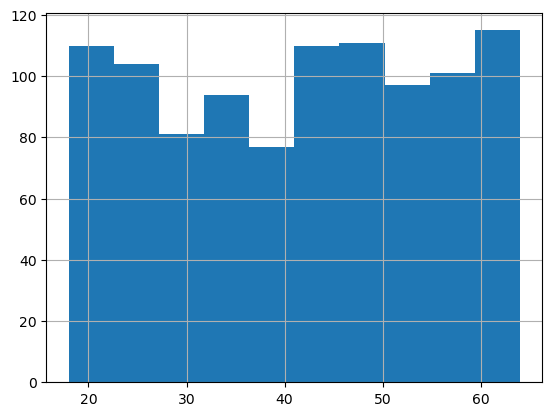

In [21]:
df['age'].hist(bins=10)

In [22]:
df['total_amount'].describe()

count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: total_amount, dtype: float64

In [23]:
sales_by_category = df.groupby('product_category').agg(
    orders=('transaction_id','count'),
    sales=('total_amount','sum'),
    avg_order=('total_amount','mean')
).sort_values('sales', ascending=False).reset_index()

In [24]:
sales_by_month = df.set_index('order_date').resample('MS').agg({
    'transaction_id':'count',
    'total_amount':'sum'
}).rename(columns={'transaction_id':'orders','total_amount':'sales'})

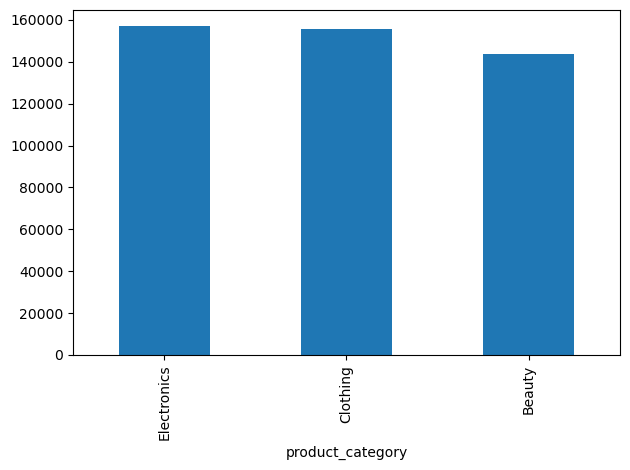

In [25]:
sales_by_category.plot(kind='bar', x='product_category', y='sales', legend=False)
plt.tight_layout()

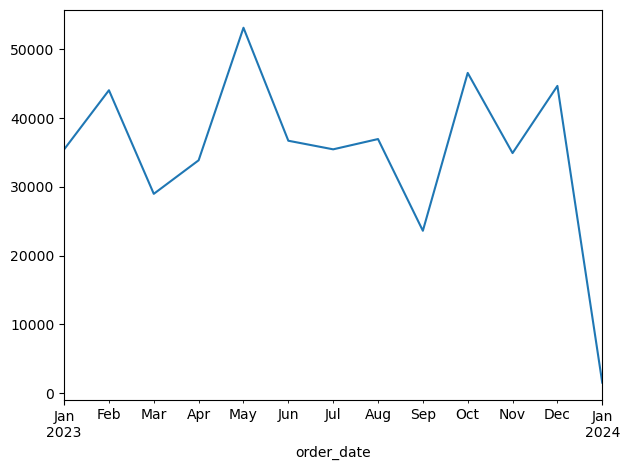

In [26]:
sales_by_month['sales'].plot(kind='line')
plt.tight_layout()

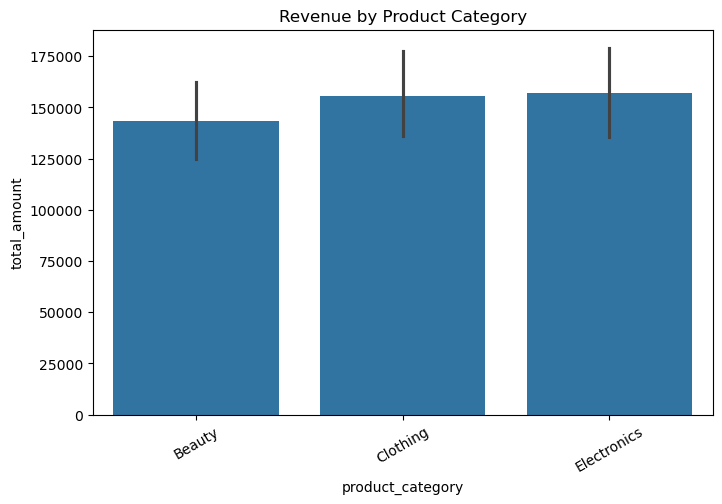

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x='product_category', y='total_amount', data=df, estimator=sum)
plt.title("Revenue by Product Category")
plt.xticks(rotation=30)
plt.show()

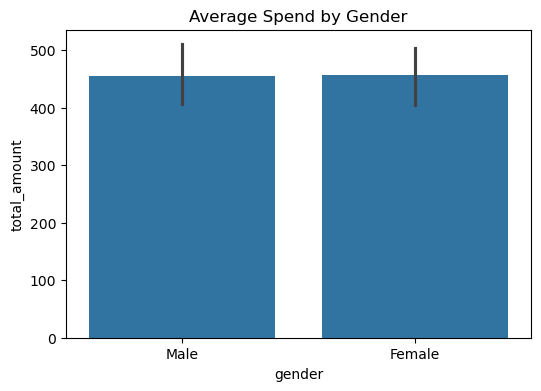

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='total_amount', data=df, estimator='mean')
plt.title("Average Spend by Gender")
plt.show()

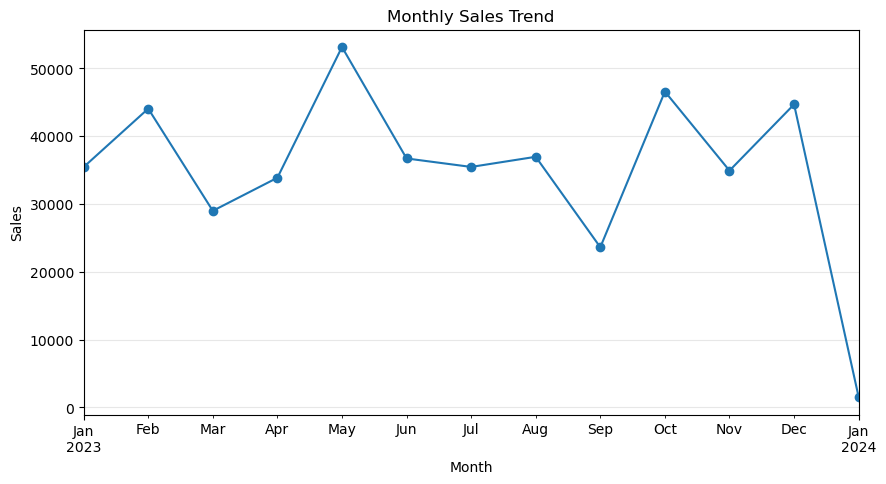

In [29]:
monthly_sales = df.set_index('order_date').resample('ME')['total_amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.show()

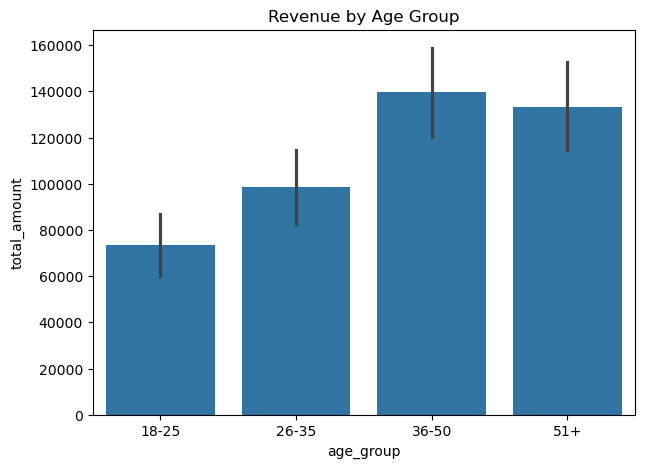

In [30]:
bins = [18, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '51+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(7,5))
sns.barplot(x='age_group', y='total_amount', data=df, estimator=sum)
plt.title("Revenue by Age Group")
plt.show()

In [31]:
repeat_customers = df.groupby('customer_id').agg(
    num_orders=('transaction_id', 'count'),
    total_spent=('total_amount', 'sum')
).query("num_orders > 1").sort_values('total_spent', ascending=False).head(10)

print(repeat_customers)

Empty DataFrame
Columns: [num_orders, total_spent]
Index: []


In [33]:
rfm = df.groupby('customer_id').agg({
    'date': 'max',
    'transaction_id': 'count',
    'total_amount': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']
print(rfm.head())

  customer_id     recency  frequency  monetary
0     CUST001  24-11-2023          1       150
1     CUST002  27-02-2023          1      1000
2     CUST003  13-01-2023          1        30
3     CUST004  21-05-2023          1       500
4     CUST005  06-05-2023          1       100


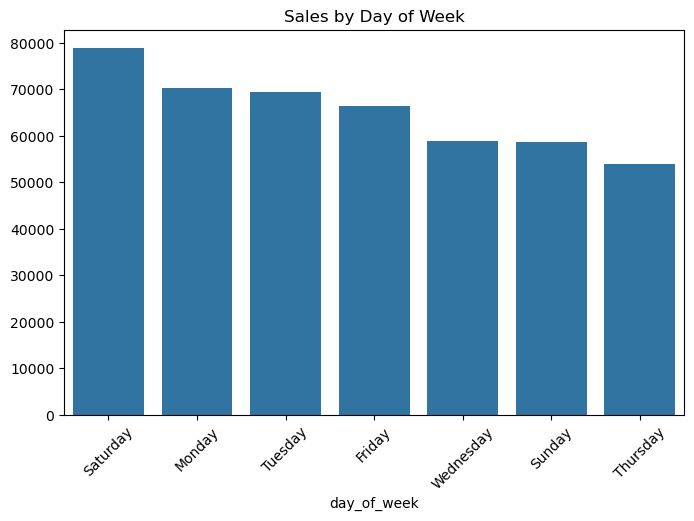

In [39]:
df['day_of_week'] = df['date'].dt.day_name()

sales_by_day = df.groupby('day_of_week')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values)
plt.title("Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

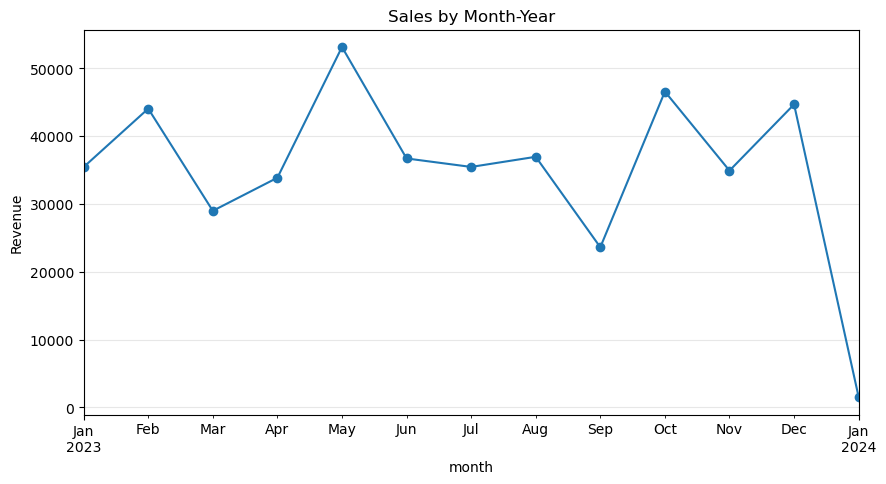

In [42]:
# Convert once before analysis
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Now create month column
df['month'] = df['date'].dt.to_period('M')

sales_by_month = df.groupby('month')['total_amount'].sum()

plt.figure(figsize=(10,5))
sales_by_month.plot(kind='line', marker='o')
plt.title("Sales by Month-Year")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()